<a href="https://colab.research.google.com/github/marcyannick1/deeplearning-j4-RNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import keras

In [2]:
# TODO : charger le CSV Airline Passengers depuis l'URL jbrownlee/Datasets
# (colonne "Passengers")

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

dataset = df["Passengers"].values

In [3]:
# TODO : convertir en float32, afficher shape et min/max

dataset = dataset.astype("float32")

print("Shape :", dataset.shape)
print("Min :", dataset.min())
print("Max :", dataset.max())

Shape : (144,)
Min : 104.0
Max : 622.0


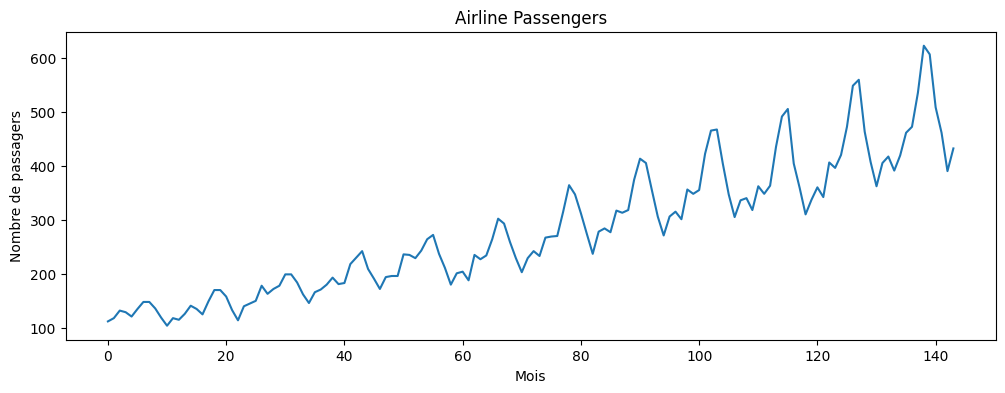

In [4]:
# TODO : afficher rapidement la série temporelle

plt.figure(figsize=(12, 4))
plt.plot(dataset)
plt.title("Airline Passengers")
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.show()

In [5]:
# TODO : normaliser avec MinMaxScaler entre 0 et 1
# (le LSTM est sensible aux grandes valeurs)

scaler = MinMaxScaler(feature_range=(0, 1))

dataset = scaler.fit_transform(
    dataset.reshape(-1, 1)
)

In [6]:
# TODO : split temporel 67/33 — jamais de shuffle sur une série temporelle

train_size = int(len(dataset) * 0.67)

train = dataset[:train_size]
test = dataset[train_size:]

In [7]:
def create_dataset(dataset, window_size=12):
    """
    Transforme une série 1D en paires (X, y) via sliding window.

    Retourne :
    X : (N - window_size, window_size, 1)
    y : (N - window_size,)
    """

    X, y = [], []

    for i in range(len(dataset) - window_size):

        # TODO : ajouter la fenêtre de valeurs précédentes dans X
        X.append(dataset[i:i + window_size])

        # TODO : ajouter la valeur suivante comme cible dans y
        y.append(dataset[i + window_size])


    # TODO : convertir X et y en tableaux numpy
    X = np.array(X)
    y = np.array(y)


    return X, y

In [8]:
WINDOW_SIZE = 12

# TODO : créer les datasets train et test avec la fenêtre glissante

X_train, y_train = create_dataset(train, WINDOW_SIZE)

X_test, y_test = create_dataset(test, WINDOW_SIZE)

In [9]:
# TODO : afficher les dimensions finales

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (84, 12, 1)
y_train : (84, 1)
X_test : (36, 12, 1)
y_test : (36, 1)
